# A python program to
demonstrate
Use drop down menu or **esc m** to toggle to markdowy and **esc y** to toggle to code 

**Run this cel**l to see the markdown resolved.

**Double click on cell** to return to edit mode.

Load the libraries required using aliases np and plt.  Before this can work the libraries must be installed in the environment.  This can be done by running the pip program manager within a bash shell.

To have a cell interpreted as a bash shell use the "magic" command %%bash at the start of the cell.

This example is using [matplotlib](https://matplotlib.org/stable/) and the [matplotlib widgets](https://matplotlib.org/stable/api/widgets_api.html#matplotlib.widgets.Slider) slider. 


> pip install ipympl matplotlib numpy

```python
# Enable interactive widgets
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
```
A list of 1000 equally spaced numbers is generated using linespace from [numpy](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)
The sine wave line is a list based on the [sin function]() which applies to every element of the list time to make a new list signal.

```python
# 1. Setup the initial data
time = np.linspace(0, 1, 1000)
initial_freq = 5
amplitude = 1
signal = amplitude * np.sin(2 * np.pi * initial_freq * time)
```

A figure is produced using the [Matplotlib](https://matplotlib.org/stable/users/explain/figure/figure_intro.html#creating-figures).  The [subplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html#matplotlib.pyplot.subplots) returns both a figure and axes.



```python
# 2. Create the figure and the line that we will update
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25) # Make room for the slider
line, = ax.plot(time, signal, lw=2, color='teal')
ax.set_ylim(-1.5, 1.5)
ax.set_title('Frequency Control Slider')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')
```

```python
# 3. Define the slider's position and range
# [left, bottom, width, height]
ax_freq = plt.axes([0.25, 0.1, 0.65, 0.03])
freq_slider = Slider(
    ax=ax_freq,
    label='Frequency [Hz] ',
    valmin=0.1,
    valmax=30.0,
    valinit=initial_freq,
)
```

```python
# 4. The update function that changes the data
def update(val):
    freq = freq_slider.val
    line.set_ydata(amplitude * np.sin(2 * np.pi * freq * time))
    fig.canvas.draw_idle() # Redraw the figure
```

```python
# 5. Connect the slider to the update function
freq_slider.on_changed(update)
```

```python
plt.show()
```

In [1]:
%%bash

pip install ipympl matplotlib numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


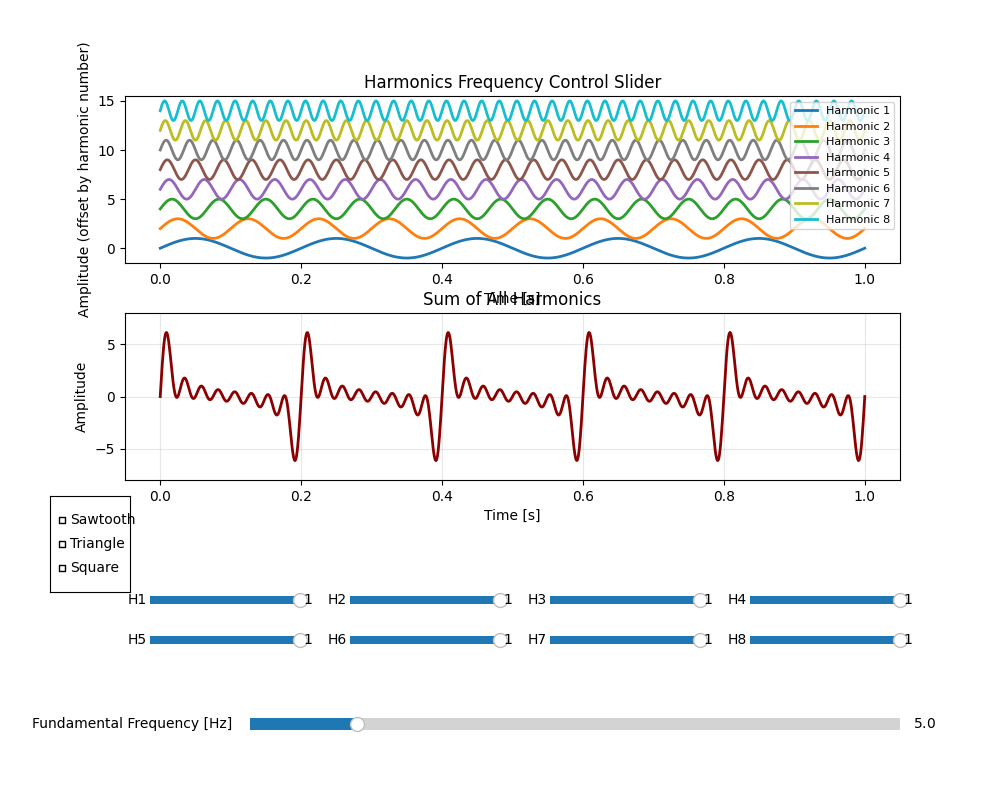

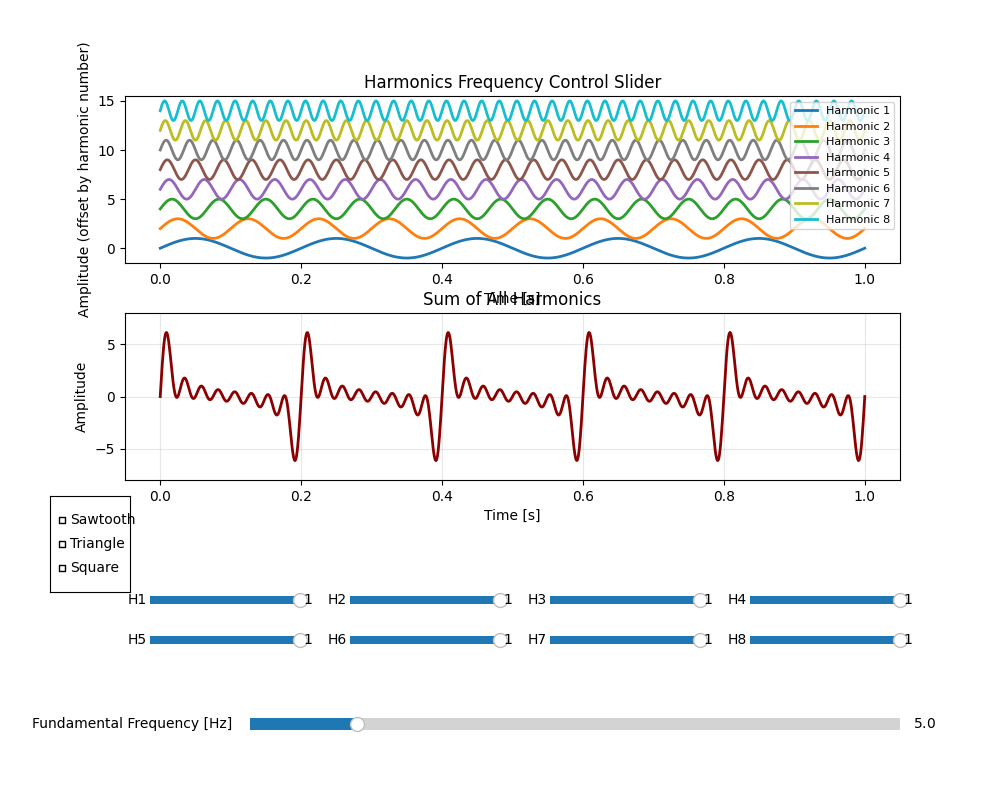

In [ ]:
# Enable interactive widgets
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, CheckButtons

# 1. Setup the initial data
time = np.linspace(0, 1, 1000)
initial_freq = 5
amplitude = 1
num_harmonics = 8  # fundamental + 7 harmonics
harmonic_amplitudes = [1.0] * num_harmonics  # Individual amplitude for each harmonic

# 2. Create the figure with 2 subplots
fig, (ax, ax_sum) = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(bottom=0.4, hspace=0.3)

# Create lines for each harmonic
lines = []
colors = plt.cm.tab10(np.linspace(0, 1, num_harmonics))

for i in range(num_harmonics):
    # Each harmonic: frequency is (i+1) times the fundamental, offset vertically by i
    harmonic_num = i + 1
    freq = harmonic_num * initial_freq
    signal = harmonic_amplitudes[i] * np.sin(2 * np.pi * freq * time) + 2*i
    line, = ax.plot(time, signal, lw=2, color=colors[i], label=f'Harmonic {harmonic_num}')
    lines.append(line)

ax.set_ylim(-1.5, (num_harmonics - 1) * 2 + 1.5)
ax.set_title('Harmonics Frequency Control Slider')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude (offset by harmonic number)')
ax.legend(loc='upper right', fontsize=8)

# Create the sum line
sum_signal = np.zeros_like(time)
for i in range(num_harmonics):
    harmonic_num = i + 1
    freq = harmonic_num * initial_freq
    sum_signal += harmonic_amplitudes[i] * np.sin(2 * np.pi * freq * time)

sum_line, = ax_sum.plot(time, sum_signal, lw=2, color='darkred')
ax_sum.set_ylim(-num_harmonics, num_harmonics)
ax_sum.set_title('Sum of All Harmonics')
ax_sum.set_xlabel('Time [s]')
ax_sum.set_ylabel('Amplitude')
ax_sum.grid(True, alpha=0.3)

# 3. Define waveform preset functions
def set_sawtooth(label):
    """Set harmonic amplitudes for sawtooth wave (1/n series)"""
    for i in range(num_harmonics):
        harmonic_amplitudes[i] = 1.0 / (i + 1)
        amplitude_sliders[i].set_val(harmonic_amplitudes[i])
    update(None)

def set_triangle(label):
    """Set harmonic amplitudes for triangle wave (odd harmonics only, 1/n² series)"""
    for i in range(num_harmonics):
        if (i + 1) % 2 == 1:  # Odd harmonics only
            harmonic_amplitudes[i] = 1.0 / ((i + 1) ** 2)
        else:
            harmonic_amplitudes[i] = 0.0
        amplitude_sliders[i].set_val(harmonic_amplitudes[i])
    update(None)

def set_square(label):
    """Set harmonic amplitudes for square wave (odd harmonics only, 1/n series)"""
    for i in range(num_harmonics):
        if (i + 1) % 2 == 1:  # Odd harmonics only
            harmonic_amplitudes[i] = 1.0 / (i + 1)
        else:
            harmonic_amplitudes[i] = 0.0
        amplitude_sliders[i].set_val(harmonic_amplitudes[i])
    update(None)

# 3a. Create checkboxes for waveform presets
ax_check = plt.axes([0.05, 0.26, 0.08, 0.12])
check_buttons = CheckButtons(ax_check, ('Sawtooth', 'Triangle', 'Square'))

_updating_checkboxes = False

def on_waveform_selected(label):
    """Handle waveform checkbox selection - only one can be active at a time"""
    global _updating_checkboxes
    if _updating_checkboxes:
        return
    _updating_checkboxes = True
    try:
        if label == 'Sawtooth':
            check_buttons.set_active(0)  # Only Sawtooth active
            set_sawtooth(label)
        elif label == 'Triangle':
            check_buttons.set_active(1)  # Only Triangle active
            set_triangle(label)
        elif label == 'Square':
            check_buttons.set_active(2)  # Only Square active
            set_square(label)
    finally:
        _updating_checkboxes = False

check_buttons.on_clicked(on_waveform_selected)

# 3b. Create amplitude sliders for each harmonic
amplitude_sliders = []
for i in range(num_harmonics):
    # Position in a 2x4 grid above the frequency slider
    col = i % 4
    row = i // 4
    ax_amp = plt.axes([0.15 + col * 0.2, 0.24 - row * 0.05, 0.15, 0.02])
    amp_slider = Slider(
        ax=ax_amp,
        label=f'H{i+1}',
        valmin=0.0,
        valmax=1.0,
        valinit=1.0,
    )
    amplitude_sliders.append(amp_slider)

# 4. Define the frequency slider
ax_freq = plt.axes([0.25, 0.08, 0.65, 0.03])
freq_slider = Slider(
    ax=ax_freq,
    label='Fundamental Frequency [Hz] ',
    valmin=0.1,
    valmax=30.0,
    valinit=initial_freq,
)

# 5. The update function that changes the data for all harmonics
def update(val):
    fundamental_freq = freq_slider.val
    # Update amplitudes from sliders
    for i in range(num_harmonics):
        harmonic_amplitudes[i] = amplitude_sliders[i].val
    
    sum_signal = np.zeros_like(time)
    for i, line in enumerate(lines):
        # Harmonic frequency is (i+1) times the fundamental
        harmonic_num = i + 1
        harmonic_freq = harmonic_num * fundamental_freq
        signal = harmonic_amplitudes[i] * np.sin(2 * np.pi * harmonic_freq * time) + 2*i
        line.set_ydata(signal)
        # Add to sum (without the offset)
        sum_signal += harmonic_amplitudes[i] * np.sin(2 * np.pi * harmonic_freq * time)
    sum_line.set_ydata(sum_signal)
    fig.canvas.draw_idle() # Redraw the figure

# 6. Connect all sliders to the update function
freq_slider.on_changed(update)
for amp_slider in amplitude_sliders:
    amp_slider.on_changed(update)

plt.show()